<a href="https://colab.research.google.com/github/gxth969-pixel/ict_assignments/blob/main/case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **________________________________________________**

# ***Case Study: Olympic Medal Data Analysis***
# **________________________________________________**

# PART 1 — Data Understanding


In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/athlete_events - medal.csv")

# Display first 5 rows
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246864 entries, 0 to 246863
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      246864 non-null  int64  
 1   Name    246864 non-null  object 
 2   Sex     246864 non-null  object 
 3   Age     238197 non-null  float64
 4   Height  192051 non-null  float64
 5   Weight  189517 non-null  float64
 6   Team    246864 non-null  object 
 7   NOC     246864 non-null  object 
 8   Games   246864 non-null  object 
 9   Year    246863 non-null  float64
 10  Season  246863 non-null  object 
 11  City    246863 non-null  object 
 12  Sport   246863 non-null  object 
 13  Event   246863 non-null  object 
 14  Medal   35956 non-null   object 
dtypes: float64(4), int64(1), object(10)
memory usage: 28.3+ MB


In [23]:
missing_values = df.isnull().sum()
print("Number of missing values per column:\n", missing_values)

Number of missing values per column:
 ID             0
Name           0
Sex            0
Age         8667
Height     54813
Weight     57347
Team           0
NOC            0
Games          0
Year           1
Season         1
City           1
Sport          1
Event          1
Medal     210908
dtype: int64


# PART 2 — Medal Filtering


In [7]:
# Create a new DataFrame with only medal winners
medal_winners = df[df['Medal'].notna()]

# Display the first 5 rows
medal_winners.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014.0,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948.0,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


# PART 3 — Country Analysis


In [8]:
# Count total medals
total_medals = df['Medal'].notna().sum()

print("Total Medal Count:", total_medals)

Total Medal Count: 35956


In [18]:
medals_per_country = medal_winners.groupby('NOC')['Medal'].count().sort_values(ascending=False)

print("Total Medals Won by Each Country (Top 10):\n")
print(medals_per_country.head(10))

Total Medals Won by Each Country (Top 10):

NOC
USA    5161
URS    2271
GBR    1904
GER    1883
FRA    1714
ITA    1530
SWE    1433
CAN    1239
AUS    1219
HUN    1048
Name: Medal, dtype: int64


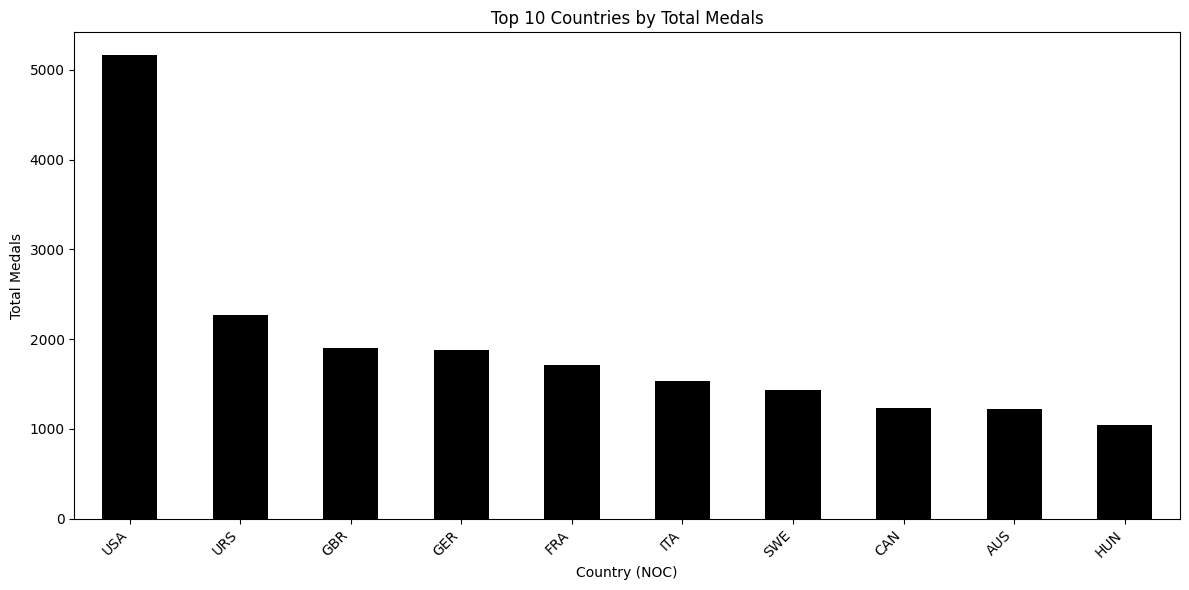

In [25]:
import matplotlib.pyplot as plt

# top 10 countries
top_10_countries = medals_per_country.head(10)

# bar chart
plt.figure(figsize=(12, 6))
top_10_countries.plot(kind='bar', color='k')
plt.title('Top 10 Countries by Total Medals')
plt.xlabel('Country (NOC)')
plt.ylabel('Total Medals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Top 10 Countries by Gold Medals:

NOC
USA    2400
URS     985
GER     643
GBR     627
ITA     532
FRA     488
SWE     441
CAN     430
HUN     402
NOR     370
Name: Medal, dtype: int64


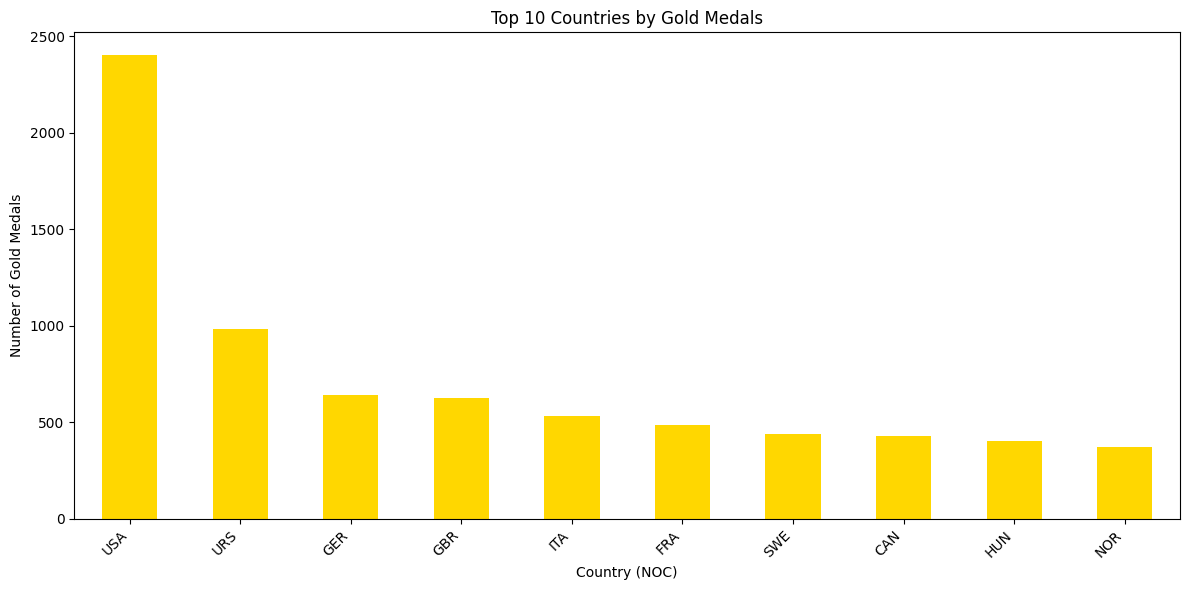

In [26]:
# Filter for only Gold medals
gold_medals = medal_winners[medal_winners['Medal'] == 'Gold']

# Find top 10 countries with most Gold medals
gold_medals_per_country = gold_medals.groupby('NOC')['Medal'].count().sort_values(ascending=False)
top_10_gold_countries = gold_medals_per_country.head(10)

print("Top 10 Countries by Gold Medals:\n")
print(top_10_gold_countries)

# Plot a bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
top_10_gold_countries.plot(kind='bar', color='gold')
plt.title('Top 10 Countries by Gold Medals')
plt.xlabel('Country (NOC)')
plt.ylabel('Number of Gold Medals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# PART 4 — Gender Analysis

Total Medals by Gender:
 Sex
M    25972
F     9984
Name: count, dtype: int64


/tmp/ipykernel_245/3367519766.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=medal_winners, palette='viridis')


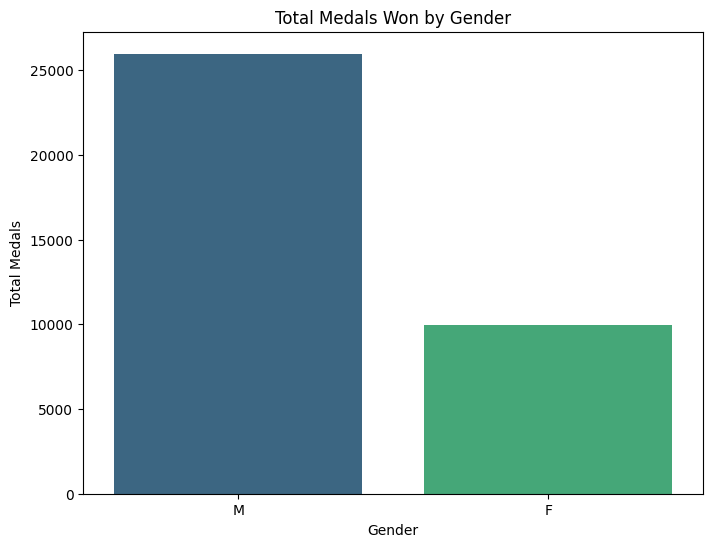

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count total medals won by Male and Female athletes
gender_medals = medal_winners['Sex'].value_counts()

print("Total Medals by Gender:\n", gender_medals)

# Visualize using a bar chart (countplot)
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', data=medal_winners, palette='viridis')
plt.title('Total Medals Won by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Medals')
plt.show()

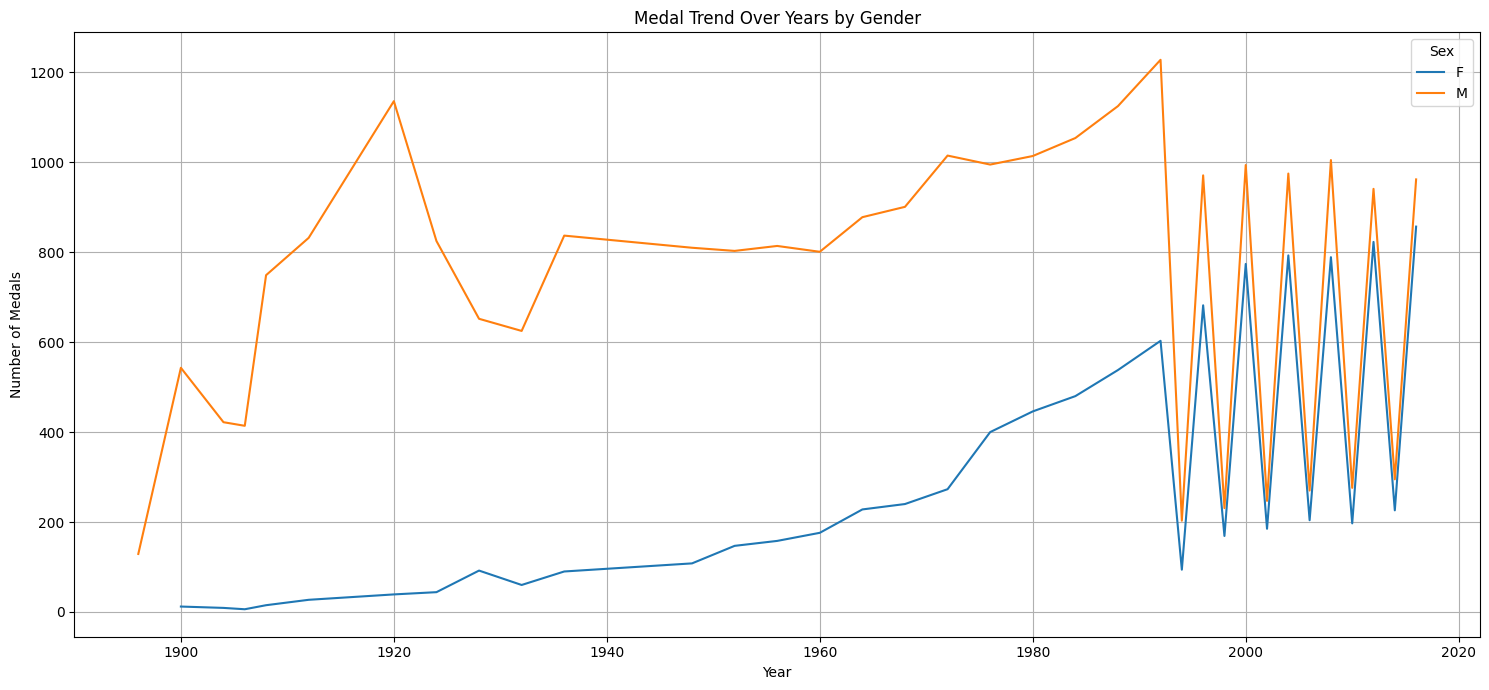

In [28]:
# Group data by Year and Sex and count medals
gender_medals_trend = medal_winners.groupby(['Year', 'Sex'])['Medal'].count().unstack()

# Plot medal trend over years for Male and Female athletes
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
gender_medals_trend.plot(kind='line', ax=plt.gca())
plt.title('Medal Trend Over Years by Gender')
plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.legend(title='Sex')
plt.grid(True)
plt.tight_layout()
plt.show()

# PART 5 — Sport Analysis

Top 10 Sports by Total Medals:

Sport
Athletics     3654
Swimming      2717
Rowing        2683
Gymnastics    2049
Fencing       1599
Football      1439
Ice Hockey    1414
Hockey        1366
Wrestling     1178
Cycling       1131
Name: Medal, dtype: int64


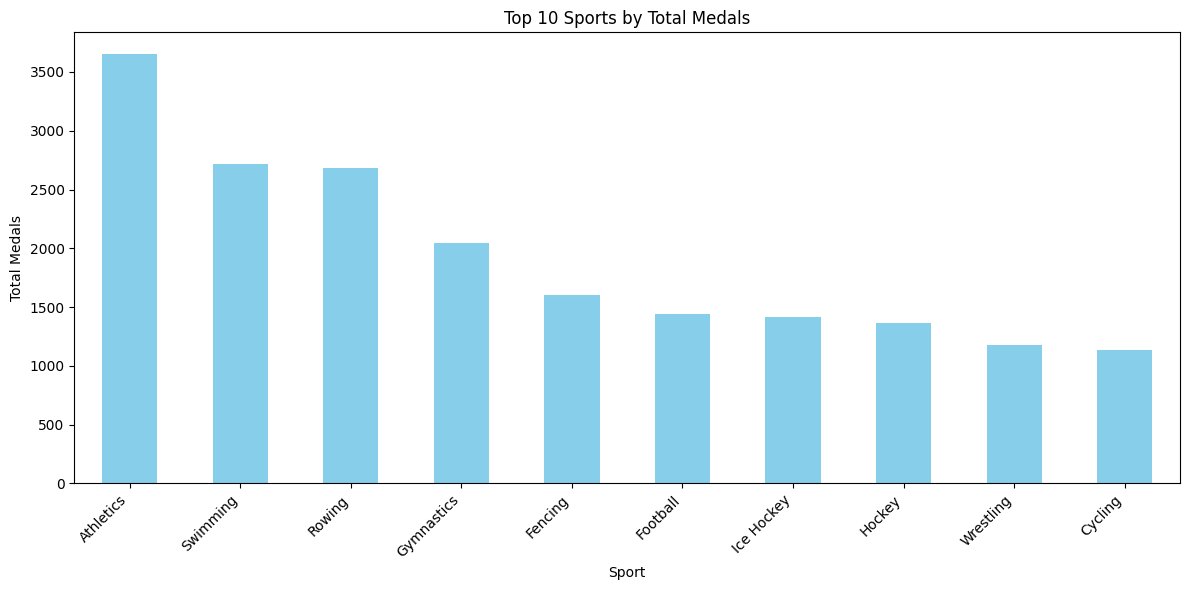

In [29]:
# Find top 10 sports by total medals
medals_per_sport = medal_winners.groupby('Sport')['Medal'].count().sort_values(ascending=False)
top_10_sports = medals_per_sport.head(10)

print("Top 10 Sports by Total Medals:\n")
print(top_10_sports)

# Plot a bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
top_10_sports.plot(kind='bar', color='skyblue')
plt.title('Top 10 Sports by Total Medals')
plt.xlabel('Sport')
plt.ylabel('Total Medals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [31]:
# Group by Sport and count Gold medals
gold_medals_per_sport = gold_medals.groupby('Sport')['Medal'].count().sort_values(ascending=False)

# Get the sport with the highest number of Gold medals
top_gold_sport = gold_medals_per_sport.head(1)

print("Sport with the highest number of Gold medals:")
print(top_gold_sport)

Sport with the highest number of Gold medals:
Sport
Athletics    1230
Name: Medal, dtype: int64


# PART 6 — Year-wise Analysis


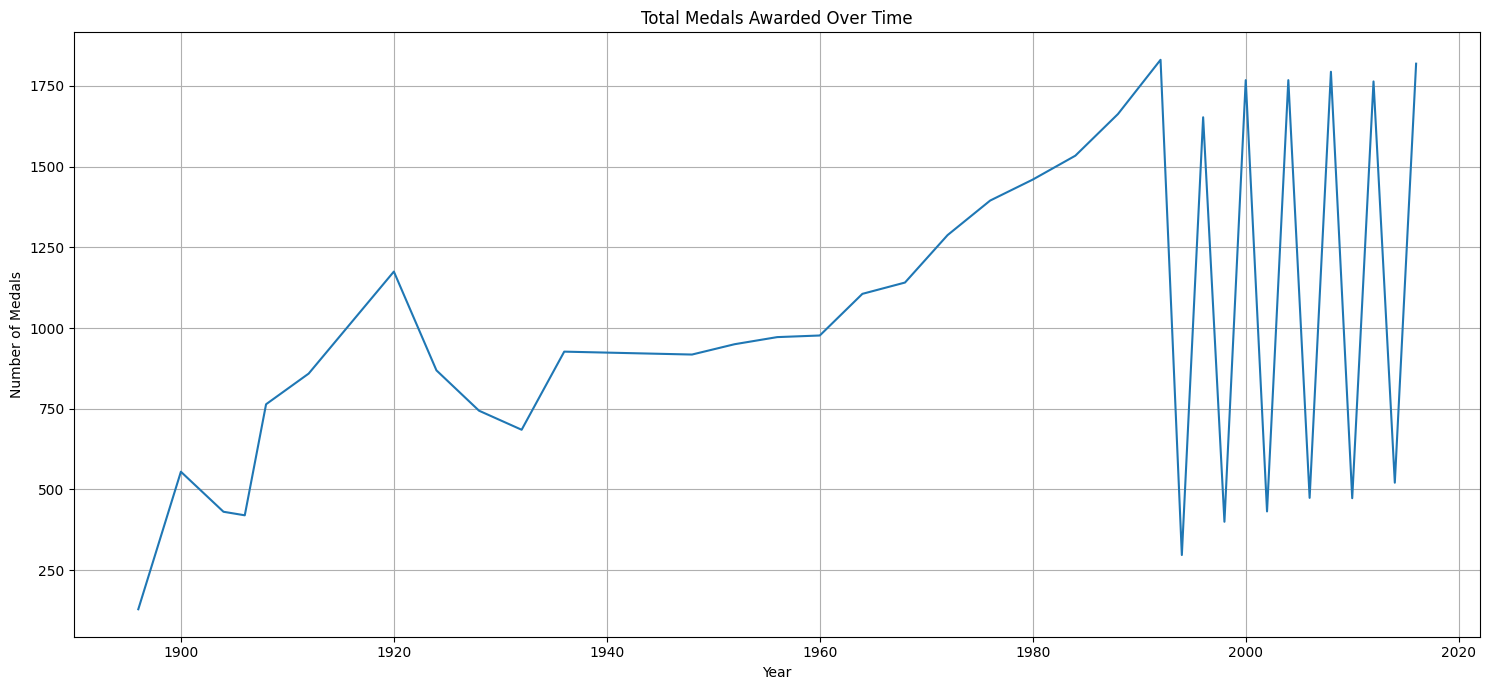

In [32]:
# Calculate total medals per year
total_medals_per_year = medal_winners.groupby('Year')['Medal'].count()

# Plot the trend of total medals over time
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
total_medals_per_year.plot(kind='line')
plt.title('Total Medals Awarded Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
best_year = total_medals_per_year.idxmax()
highest_medals = total_medals_per_year.max()

print(f"The year with the highest number of medals awarded was {int(best_year)} with {int(highest_medals)} medals.")

The year with the highest number of medals awarded was 1992 with 1831 medals.


# PART 7 — Age Analysis

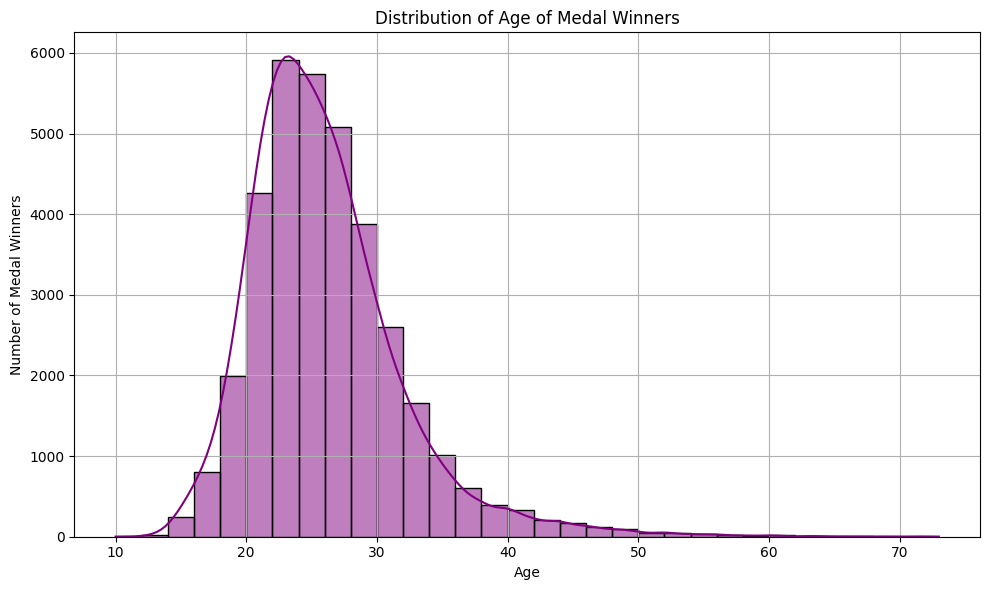

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop rows where 'Age' is NaN, as a medal winner must have an age
medal_winners_age = medal_winners.dropna(subset=['Age'])

plt.figure(figsize=(10, 6))
sns.histplot(medal_winners_age['Age'], bins=range(10, 70, 2), kde=True, color='purple')
plt.title('Distribution of Age of Medal Winners')
plt.xlabel('Age')
plt.ylabel('Number of Medal Winners')
plt.grid(True)
plt.tight_layout()
plt.show()

# Based on the histogram, we can observe the most common winning age range.
# The peak of the histogram will indicate the most frequent age range.

In [35]:
average_age_by_medal = medal_winners_age.groupby('Medal')['Age'].mean()
print("Average Age by Medal Type:\n", average_age_by_medal)

Average Age by Medal Type:
 Medal
Bronze    25.902074
Gold      25.906690
Silver    26.027022
Name: Age, dtype: float64


# PART 8 — Correlation & Numerical Insight


Correlation Matrix:
              Age    Height    Weight
Age     1.000000  0.138186  0.211646
Height  0.138186  1.000000  0.795568
Weight  0.211646  0.795568  1.000000


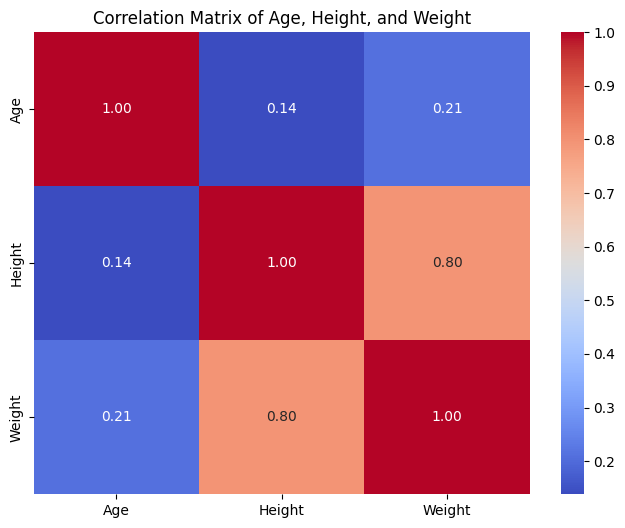


The two most correlated variables are Height and Weight with a correlation of 0.80.


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select numerical columns for correlation analysis
numerical_cols = ['Age', 'Height', 'Weight']
correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix:\n", correlation_matrix)

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Age, Height, and Weight')
plt.show()

# Identify the two most correlated variables
# Extract the upper triangle of the correlation matrix to avoid self-correlation and duplicate pairs
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Find the column with the maximum correlation value
max_corr_pair = upper_tri.stack().idxmax()
max_corr_value = upper_tri.stack().max()

print(f"\nThe two most correlated variables are {max_corr_pair[0]} and {max_corr_pair[1]} with a correlation of {max_corr_value:.2f}.")

# PART 9 — Mini Investigation (Open-Ended)


Total medals: 5161
Gold medals: 2400
Best sport:
 Sport
Athletics    1006
Name: Medal, dtype: int64


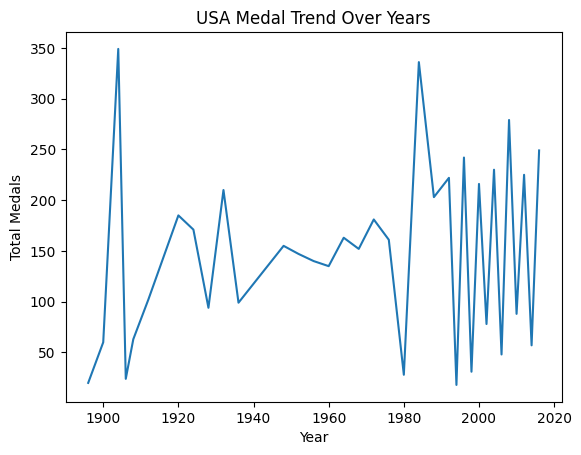

In [40]:
# Remove rows without medals
medal_winners = df.dropna(subset=["Medal"])
# Choose country
country = medal_winners[medal_winners["NOC"] == "USA"]
# Total medals
total_medals = country["Medal"].count()
print("Total medals:", total_medals)
# Gold medals
gold_medals = country[country["Medal"] == "Gold"]["Medal"].count()
print("Gold medals:", gold_medals)
# Best sport (most medals)
best_sport = country.groupby("Sport")["Medal"].count().sort_values(ascending=False).head(1)
print("Best sport:\n", best_sport)
# Medal trend over years
trend = country.groupby("Year")["Medal"].count()
trend.plot(kind="line", title="USA Medal Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Medals")
plt.show()

In [42]:
# Define 'sport' for analysis (e.g., using the top sport from previous analysis)
sport = medal_winners[medal_winners["Sport"] == "Athletics"]
# Country that dominates
top_country = sport.groupby("NOC")["Medal"].count().sort_values(ascending=False).head(1)
print("Dominating Country:\n", top_country)
# Gender participation
gender = sport["Sex"].value_counts()
print("Gender Participation:\n", gender)
# Average age of winners
avg_age = sport["Age"].mean()
print("Average Age of Winners:", avg_age)


Dominating Country:
 NOC
USA    1006
Name: Medal, dtype: int64
Gender Participation:
 Sex
M    2481
F    1173
Name: count, dtype: int64
Average Age of Winners: 25.02009911894273
